<a href="https://colab.research.google.com/github/Mystic1412/CS536Assignment1/blob/main/WrittenPart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Ford Ranger Models Price Prediction


Final unscaled minimum theta after training:
$\theta_0$ = 0.014409599969484708
$\theta_1$ = 9.735110701960915

Final unscaled maximum theta after training:
$\theta_0$ = 0.01797665426659515
$\theta_1$ = 16.73130004807617

Final scaled minimum theta after training:
$\theta_0$ = 0.015205321252072008
$\theta_1$ = 0.7786728916402945

Final scaled maximum theta after training:
$\theta_0$ = 0.01202170683764288
$\theta_1$ = 0.5211963180600709


After seeing the unscaled thetas to the scaled thetas I can see a clear difference in how the scaled thetas changes drastically for espectally for theta 1 that affects the predictions for the min and max price predictions. When I look at the unscaled predictions I don't think the model did well at all because the predictions are all in the same thousands like for minimum price all the predicted price is around 19k and that's realistically isn't true since when looking at other year you can see they're all around different price amounts in the thousands. Looking at the graph the predicted amount is in a straight line which isn't a very good prediction. Now compare to the scaled models I can see a different in the predictions in the graph since the predicted amount has an positive slope compared to having basically a straight line. Also when looking at the predicted prices it's also in different thousands like the scaled minimum predicted price range from 19k to 23k. For the next-generation Ranger 2026 the predicted price range is $27593.58 - $39872.41, and I wouldn't buy the next generation Ranger because I think the prediction is falling short of the actual prices because of inflation that the prices jumped by 10,000 between 2023 and 2024 that the past prices is pulling the price prediction down since the jump is so recent and there's not much data to help with predicting the more recent Ranger prices. I think a way to improve the model would be cutting some of the data out like don't include anything before 2000s since those prices are pulling down the prediction and getting rid of those data could help move the prediction more closer since there isn't more data to pull the predicted price down as much.

**Cost Function**
$$J(\theta)=\frac{1}{m}\sum_{i=1}^{m}((e^{(i)})^2+0.1(e^{(i)})^4)$$

**Error Definition**
$$e^{(i)}=h_{\theta}(x^{(i)})-y^{(i)}$$

**Gradient with Respect to $\theta_0$**
$$\frac{\partial J}{\partial \theta_{0}}=\frac{1}{m}\sum_{i=1}^{m}(2e^{(i)} +0.4(e^{(i)})^3)$$

**Gradient with Respect to $\theta_1$**
$$\frac{\partial J}{\partial \theta_{1}}=\frac{1}{m}\sum_{i=1}^{m}(2e^{(i)} +0.4(e^{(i)})^3)x^{(i)}$$

### 1. Unscaled Minimum Price Model (MinCostPredict.py)
Used to predict the minimum price between 2012 - 2018

Final Weights: theta0 = 0.014409599969484708, theta1 = 9.735110701960915
Predicted minimum price for 2012: $19587.06
Predicted minimum price for 2013: $19596.79
Predicted minimum price for 2014: $19606.53
Predicted minimum price for 2015: $19616.26
Predicted minimum price for 2016: $19626.00
Predicted minimum price for 2017: $19635.73
Predicted minimum price for 2018: $19645.47


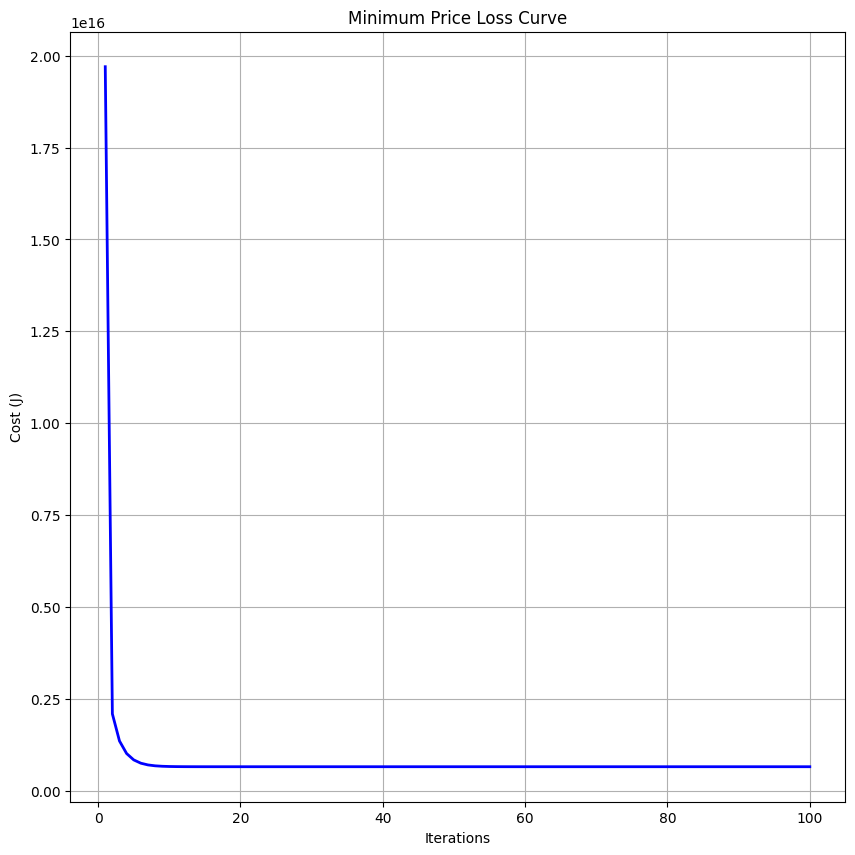

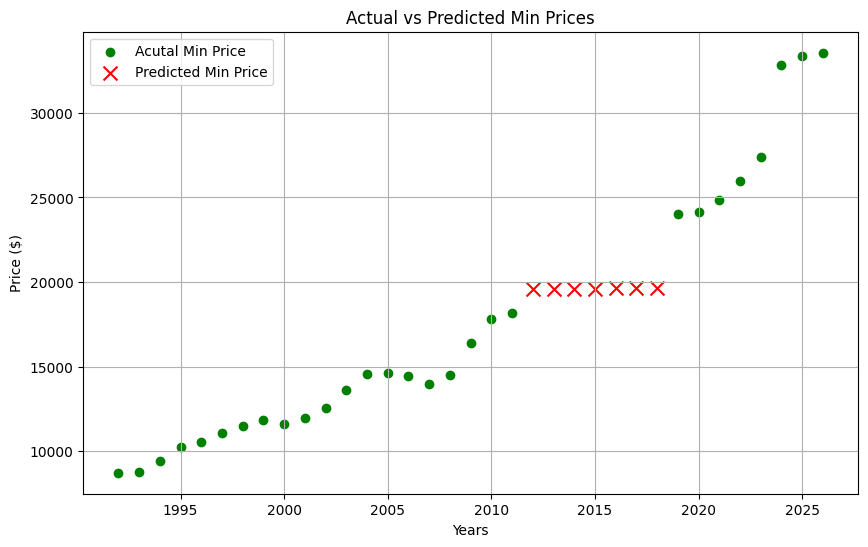

In [1]:
#used so the program can run in Juypter
#MinCostPredict.py

#for plotting the data points
import matplotlib.pyplot as plot

#the data gathered from cars.com
years = [2026, 2025, 2024, 2023, 2022, 2021, 2020, 2019,
2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002, 2001, 2000, 1999, 1998, 1997, 1996, 1995, 1994, 1993, 1992]

Minprice = [33550, 33350, 32820, 27400, 25980, 24820, 24110, 24000,
18160, 17820, 16375, 14490, 13970, 14450, 14610, 14575, 13645, 12565, 11960, 11580, 11845, 11485, 11070, 10575, 10224, 9449, 8781, 8730]

m = len(years)
#starting with small weights for baseline
weight0 = 0.01
weight1 = 0.5

#changed the learning rate from 0.0001 to 0.000000000000001 because of overflow
LearningRate = 0.000000000000001

CostHistory = [] #To store the cost for plotting later
for i in range(100):
    totalCost = 0
    gradient0 = 0
    gradient1 = 0

    #loops through every data point
    for j in range(m): #this is the m above the sigma
        x = years [j]
        y = Minprice[j]

        h=weight0 + (weight1*x)

        #error rate calulate
        e = h-y

        #finding the cost J = (e^2) + 0.1 (e^4)
        cost = (e**2) +0.1 * (e**4)
        totalCost += cost

        #calculate gradients using the deriverative formulas
        gradient0 += (2*e)+0.4*(e**3)
        gradient1 += ((2*e)+0.4*(e**3))*x

    AvgCost = totalCost/m
    CostHistory.append(AvgCost)

    avgGradient0 = gradient0/m
    avgGradient1 = gradient1/m

    #updating the weights as needed
    weight0 = weight0 - (LearningRate * avgGradient0)
    weight1 = weight1 - (LearningRate * avgGradient1)

print(f"Final Weights: theta0 = {weight0}, theta1 = {weight1}")


MissingYear = [2012,2013, 2014, 2015, 2016, 2017, 2018]
PredictPrice = []

#using the weight found I used it to predict the min cost for 2012-2018 and rounded to 2 decimal places
for year in MissingYear:
    prediction = weight0 + (weight1*year)
    PredictPrice.append(prediction)
    print(f"Predicted minimum price for {year}: ${prediction:.2f}")


iterations = range(1, 101)

plot.figure(figsize=(10,10)) #creates the canvas size
plot.plot(iterations, CostHistory, color="blue", linewidth=2) #goes through 1-100 and puts the CostHistory from each iternation
plot.title("Minimum Price Loss Curve")
plot.xlabel("Iterations")
plot.ylabel("Cost (J)")
plot.grid(True) #have a grid background
#plot.savefig("MinPrice_LossCurve.png")
plot.show()

plot.figure(figsize=(10,6))
#Plot the data from the website
plot.scatter(years, Minprice, color="green", label="Acutal Min Price" )

#Plot the missing data from 2012-2018
plot.scatter(MissingYear, PredictPrice, color="red", marker="x", s=100, label="Predicted Min Price")
plot.title("Actual vs Predicted Min Prices")
plot.xlabel("Years")
plot.ylabel("Price ($)")
plot.legend()
plot.grid(True)
#plot.savefig("YeartoMinPrice.png")
plot.show()

### 2. Unscaled Maximum Price Model (MaxCostPredict.py)

Final Weights: theta0 = 0.01797665426659515, theta1 = 16.73130004807617
Predicted maximum price for 2012: $33663.39
Predicted maximum price for 2013: $33680.12
Predicted maximum price for 2014: $33696.86
Predicted maximum price for 2015: $33713.59
Predicted maximum price for 2016: $33730.32
Predicted maximum price for 2017: $33747.05
Predicted maximum price for 2018: $33763.78


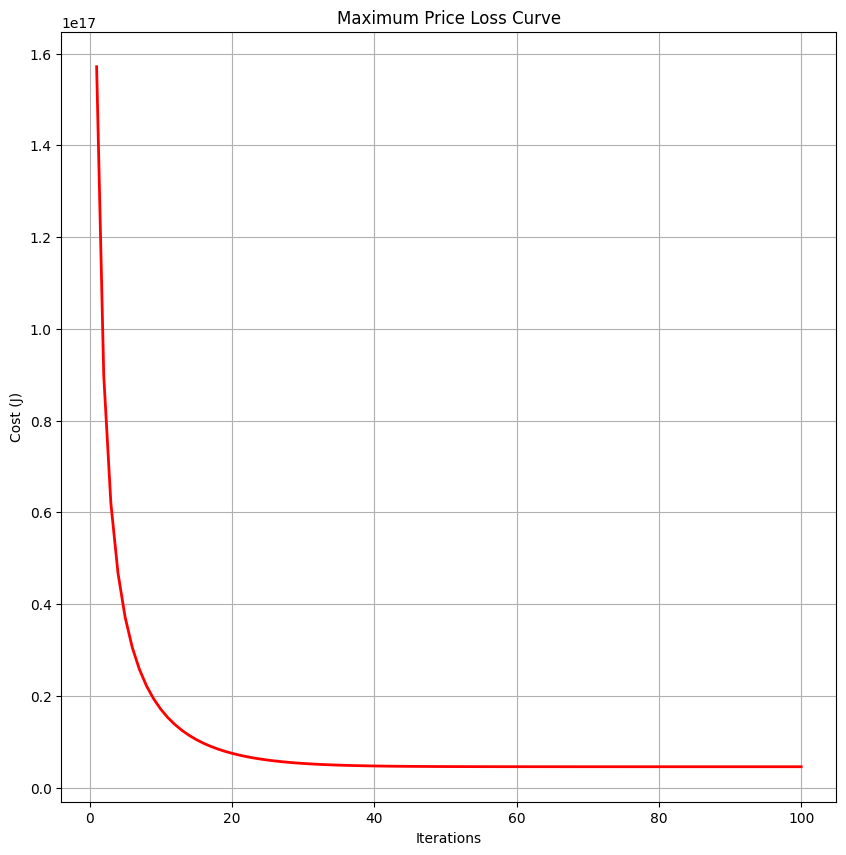

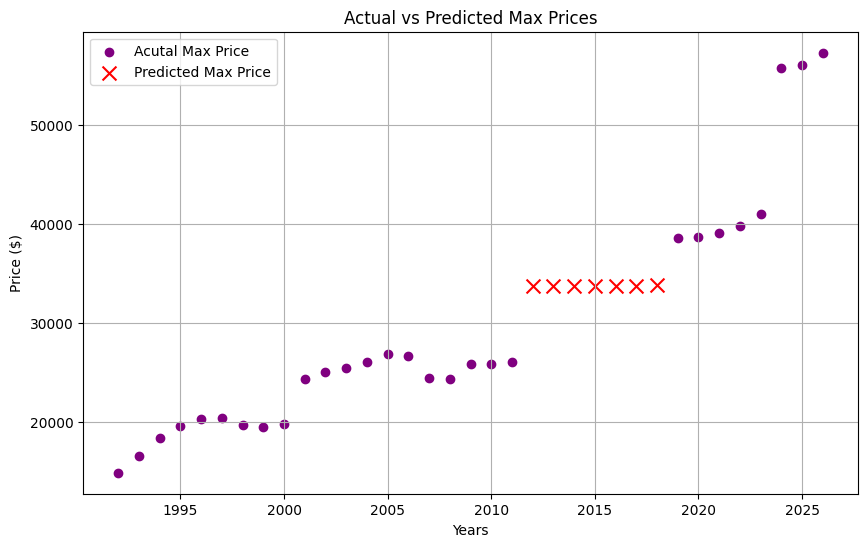

In [2]:
#for plotting the data points
import matplotlib.pyplot as plot

#the data gathered from cars.com
years = [2026, 2025, 2024, 2023, 2022, 2021, 2020, 2019,
2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002, 2001, 2000, 1999, 1998, 1997, 1996, 1995, 1994, 1993, 1992]

Maxprice = [57270, 56070, 55720, 40945, 39730, 39035, 38675, 38565,
26070, 25800, 25805, 24350, 24425,26670, 26795, 26015, 25450, 25010, 24335, 19785, 19435, 19695, 20325, 20295, 19571, 18328, 16535, 14840]

m = len(years)
#starting with small weights for baseline
weight0 = .01
weight1 = 0.5

#changed the learning rate from 0.0001 to 0.000000000000001 because of overflow
#since that learning rate was for min I had to change it for max since max has a larger number than min prices so it got changed to 0.0000000000000001
LearningRate = 0.0000000000000001

CostHistory = [] #To store the cost for plotting later
for i in range(100):
    totalCost = 0
    gradient0 = 0
    gradient1 = 0

    #loops through every data point
    for j in range(m): #this is the m above the sigma
        x = years [j]
        y = Maxprice[j]

        h=weight0 + (weight1*x)

        #error rate calulate
        e = h-y

        #finding the cost J = (e^2) + 0.1 (e^4)
        cost = (e**2) +0.1 * (e**4)
        totalCost += cost

        #calculate gradients using the deriverative formulas
        gradient0 += (2*e)+0.4*(e**3)
        gradient1 += ((2*e)+0.4*(e**3))*x

    AvgCost = totalCost/m
    CostHistory.append(AvgCost)

    avgGradient0 = gradient0/m
    avgGradient1 = gradient1/m

    #updating the weights as needed
    weight0 = weight0 - (LearningRate * avgGradient0)
    weight1 = weight1 - (LearningRate * avgGradient1)

print(f"Final Weights: theta0 = {weight0}, theta1 = {weight1}")

MissingYear = [2012,2013, 2014, 2015, 2016, 2017, 2018]
PredictPrice = []

#using the weight found I used it to predict the max cost for 2012-2018 and rounded to 2 decimal places
for year in MissingYear:
    prediction = weight0 + (weight1*year)
    PredictPrice.append(prediction)
    print(f"Predicted maximum price for {year}: ${prediction:.2f}")

iterations = range(1, 101)

plot.figure(figsize=(10,10)) #creates the canvas size
plot.plot(iterations, CostHistory, color="red", linewidth=2) #goes through 1-100 and puts the CostHistory from each iternation
plot.title("Maximum Price Loss Curve")
plot.xlabel("Iterations")
plot.ylabel("Cost (J)")
plot.grid(True) #have a grid background
#plot.savefig("MaxPrice_LossCurve.png")
plot.show()

plot.figure(figsize=(10,6))
#Plot the data from the website
plot.scatter(years, Maxprice, color="purple", label="Acutal Max Price" )

#Plot the missing data from 2012-2018
plot.scatter(MissingYear, PredictPrice, color="red", marker="x", s=100, label="Predicted Max Price")
plot.title("Actual vs Predicted Max Prices")
plot.xlabel("Years")
plot.ylabel("Price ($)")
plot.legend()
plot.grid(True)
#plot.savefig("YeartoMaxPrice.png")
plot.show()

### 3. Scaled Minimum Price Model (ScaledMinCostPredict.py)

Final Weights: theta0 = 0.015205321252072045, theta1 = 0.7786728916402945
Predicted Scaled Minimum Price for 2012: $19837.38
Predicted Scaled Minimum Price for 2013: $20391.40
Predicted Scaled Minimum Price for 2014: $20945.41
Predicted Scaled Minimum Price for 2015: $21499.43
Predicted Scaled Minimum Price for 2016: $22053.44
Predicted Scaled Minimum Price for 2017: $22607.45
Predicted Scaled Minimum Price for 2018: $23161.47
Predicted Scaled Minimum Price for 2026: $27593.58


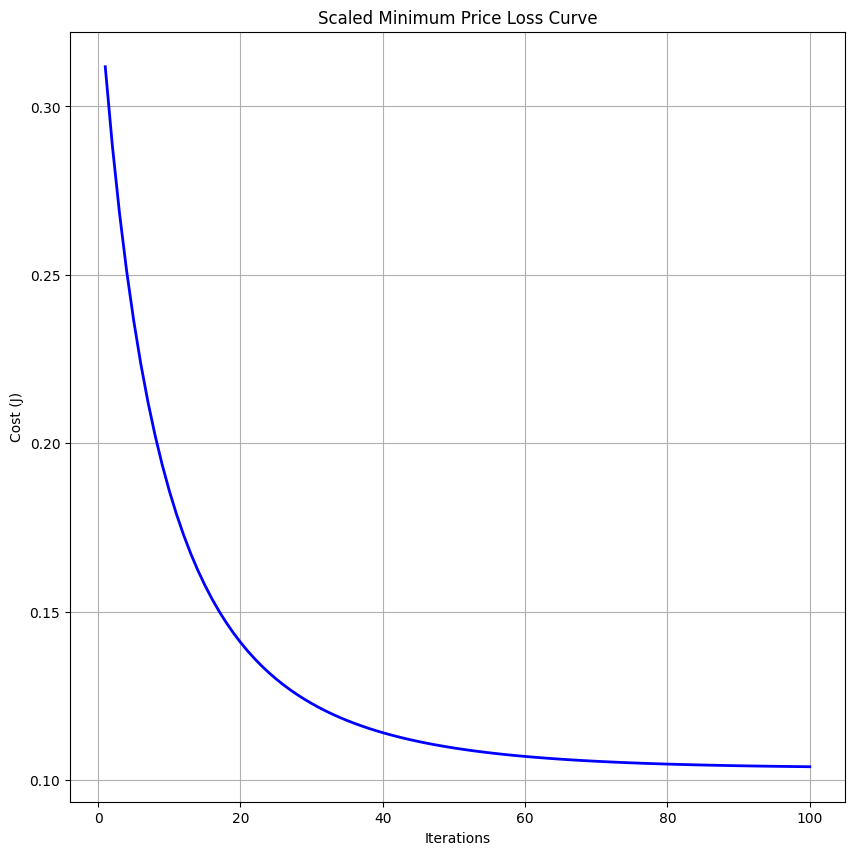

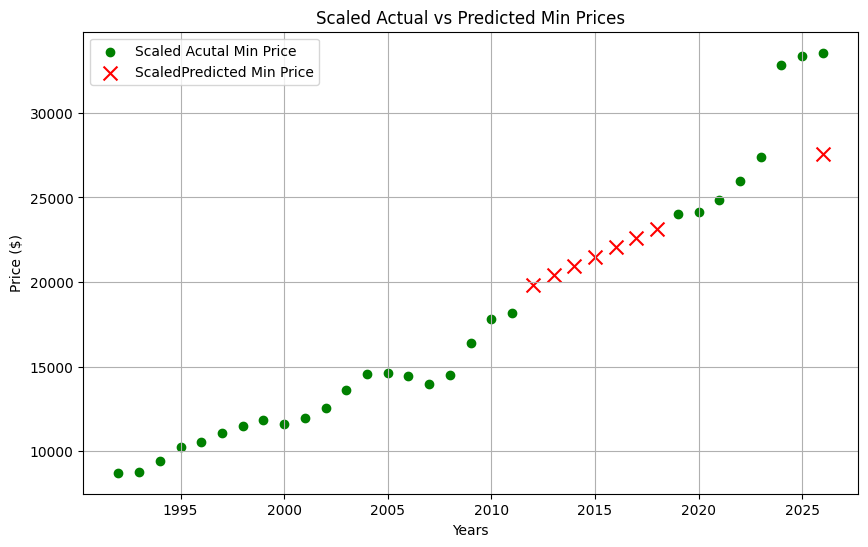

In [3]:
#for plotting the data points
import matplotlib.pyplot as plot

#the data gathered from cars.com
years = [2026, 2025, 2024, 2023, 2022, 2021, 2020, 2019,
2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002, 2001, 2000, 1999, 1998, 1997, 1996, 1995, 1994, 1993, 1992]

Minprice = [33550, 33350, 32820, 27400, 25980, 24820, 24110, 24000,
18160, 17820, 16375, 14490, 13970, 14450, 14610, 14575, 13645, 12565, 11960, 11580, 11845, 11485, 11070, 10575, 10224, 9449, 8781, 8730]

m = len(years)
#starting with small weights for baseline
weight0 = 0.01
weight1 = 0.5

#changed the learning rate from 0.0001 to 0.000000000000001 because of overflow
LearningRate = 0.02 #I picked 0.02 because I was messing with the number and seeing which number would look like it fit the best in the graph
decayRate = 0.95 #learning rate will reduce by 5% every loop

MeanYr = sum(years)/m
StdDevYr = (sum((x-MeanYr)**2 for x in years) /m ) **0.5
ScaleYr = [(x-MeanYr)/StdDevYr for x in years]

#scaling the max price
MeanMin = sum(Minprice)/m
StdDevMin = (sum((y-MeanMin)**2 for y in Minprice) /m) **0.5
ScaleMinPrice = [(y-MeanMin)/StdDevMin for y in Minprice]


CostHistory = [] #To store the cost for plotting later
for i in range(100):
    totalCost = 0
    gradient0 = 0
    gradient1 = 0

    #loops through every data point
    for j in range(m): #this is the m above the sigma
        x = ScaleYr[j]
        y = ScaleMinPrice[j]

        h=weight0 + (weight1*x)

        #error rate calulate
        e = h-y

        #finding the cost J = (e^2) + 0.1 (e^4)
        cost = (e**2) +0.1 * (e**4)
        totalCost += cost

        #calculate gradients using the deriverative formulas
        gradient0 += (2*e)+0.4*(e**3)
        gradient1 += ((2*e)+0.4*(e**3))*x

    AvgCost = totalCost/m
    CostHistory.append(AvgCost)

    avgGradient0 = gradient0/m
    avgGradient1 = gradient1/m

    #updating the weights as needed
    weight0 = weight0 - (LearningRate * avgGradient0)
    weight1 = weight1 - (LearningRate * avgGradient1)
    LearningRate = LearningRate * decayRate # to update the learnign rate as it goes

print(f"Final Weights: theta0 = {weight0}, theta1 = {weight1}")


MissingYear = [2012,2013, 2014, 2015, 2016, 2017, 2018, 2026]
PredictPrice = []

#using the weight found I used it to predict the min cost for 2012-2018 and rounded to 2 decimal places
for year in MissingYear:
    #scaling the missing years so it's not big number and now small numbers
    scaledMissingYr = (year-MeanYr)/StdDevYr

    Scaledprediction = weight0 + (weight1*scaledMissingYr)

    RealPrediction = (Scaledprediction*StdDevMin) + MeanMin #convert it back into the price numbers instead of decimals
    PredictPrice.append(RealPrediction)
    print(f"Predicted Scaled Minimum Price for {year}: ${RealPrediction:.2f}")


iterations = range(1, 101)

plot.figure(figsize=(10,10)) #creates the canvas size
plot.plot(iterations, CostHistory, color="blue", linewidth=2) #goes through 1-100 and puts the CostHistory from each iternation
plot.title("Scaled Minimum Price Loss Curve")
plot.xlabel("Iterations")
plot.ylabel("Cost (J)")
plot.grid(True) #have a grid background
#plot.savefig("ScaledMinPrice_LossCurve.png")
plot.show()

plot.figure(figsize=(10,6))
#Plot the data from the website
plot.scatter(years, Minprice, color="green", label="Scaled Acutal Min Price" )

#Plot the missing data from 2012-2018
plot.scatter(MissingYear, PredictPrice, color="red", marker="x", s=100, label="ScaledPredicted Min Price")
plot.title("Scaled Actual vs Predicted Min Prices")
plot.xlabel("Years")
plot.ylabel("Price ($)")
plot.legend()
plot.grid(True)
#plot.savefig("ScaledYeartoMinPrice.png")
plot.show()

### 4. Scaled Maximum Price Model (ScaledMaxCostPredict.py)

Final Weights: theta0 = 0.012021706837642882, theta1 = 0.5211963180600709
Predicted Scaled Maximum Price for 2012: $31847.83
Predicted Scaled Maximum Price for 2013: $32421.01
Predicted Scaled Maximum Price for 2014: $32994.20
Predicted Scaled Maximum Price for 2015: $33567.38
Predicted Scaled Maximum Price for 2016: $34140.57
Predicted Scaled Maximum Price for 2017: $34713.75
Predicted Scaled Maximum Price for 2018: $35286.93
Predicted Scaled Maximum Price for 2026: $39872.41


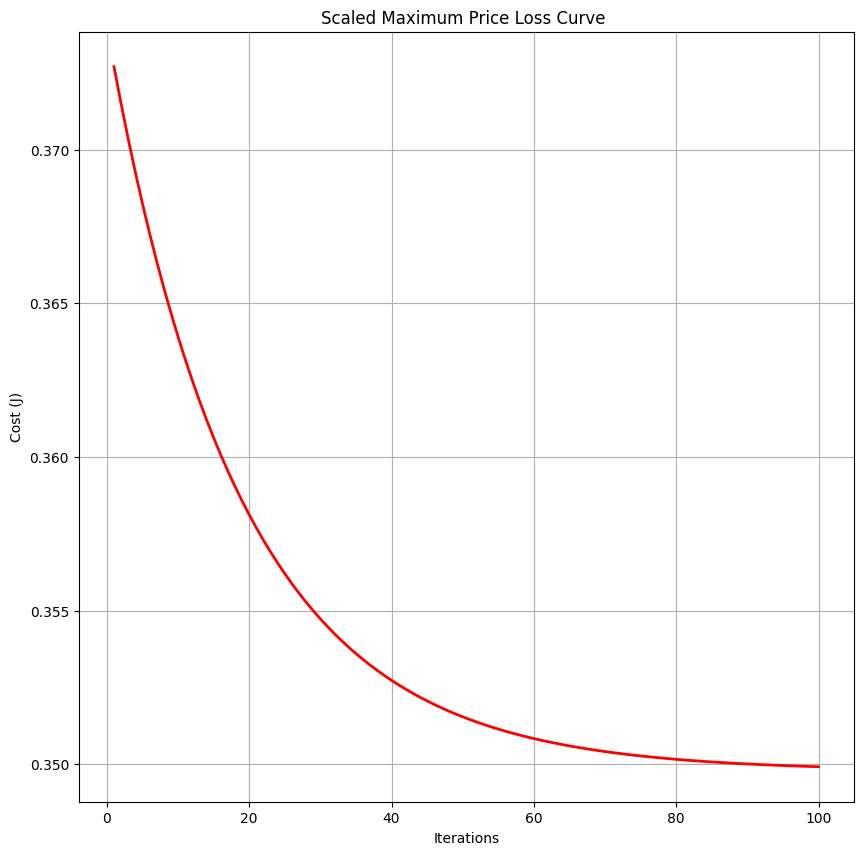

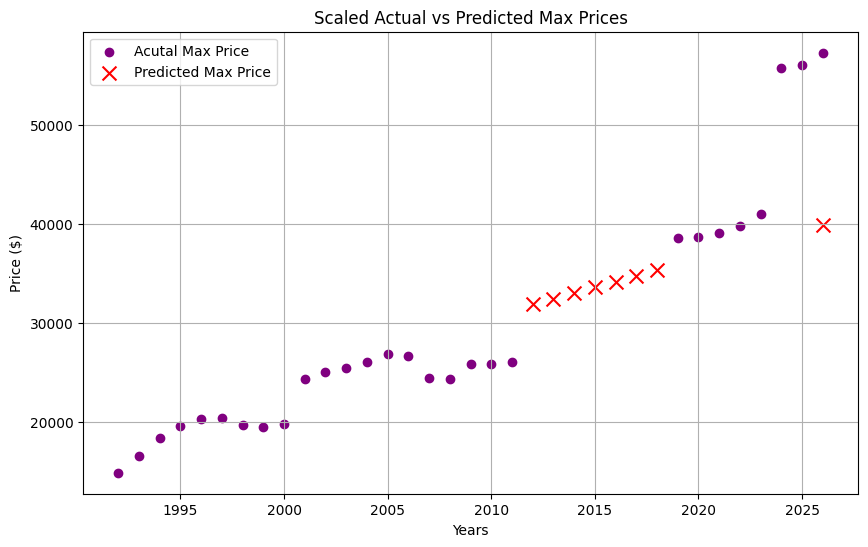

In [4]:
#for plotting the data points
import matplotlib.pyplot as plot

#the data gathered from cars.com
years = [2026, 2025, 2024, 2023, 2022, 2021, 2020, 2019,
2011, 2010, 2009, 2008, 2007, 2006, 2005, 2004, 2003, 2002, 2001, 2000, 1999, 1998, 1997, 1996, 1995, 1994, 1993, 1992]

Maxprice = [57270, 56070, 55720, 40945, 39730, 39035, 38675, 38565,
26070, 25800, 25805, 24350, 24425, 26670, 26795, 26015, 25450, 25010, 24335, 19785, 19435, 19695, 20325, 20295, 19571, 18328, 16535, 14840]


m = len(years)
#starting with small weights for baseline
weight0 = .01
weight1 = 0.5

#changed the learning rate from 0.0001 to 0.000000000000001 because of overflow
#since that learning rate was for min I had to change it for max since max has a larger number than min prices so it got changed to 0.0000000000000001
LearningRate = 0.001 #played around with the number until it's around the middle between the two yrs
decayRate = 0.95 #learning rate will reduce by 5% every loop


#scaling the year
MeanYr = sum(years)/m
StdDevYr = (sum((x-MeanYr)**2 for x in years)/m) **0.5
ScaleYr = [(x-MeanYr)/StdDevYr for x in years]

#scaling the max price
MeanMax = sum(Maxprice)/m
StdDevMax = (sum((y-MeanMax)**2 for y in Maxprice) /m) **0.5
ScaleMaxPrice = [(y-MeanMax)/StdDevMax for y in Maxprice]

CostHistory = [] #To store the cost for plotting later
for i in range(100):
    totalCost = 0
    gradient0 = 0
    gradient1 = 0

    #loops through every data point
    for j in range(m): #this is the m above the sigma
        x = ScaleYr[j]
        y = ScaleMaxPrice[j]

        h=weight0 + (weight1*x)

        #error rate calulate
        e = h-y

        #finding the cost J = (e^2) + 0.1 (e^4)
        cost = (e**2) +0.1 * (e**4)
        totalCost += cost

        #calculate gradients using the deriverative formulas
        gradient0 += (2*e)+0.4*(e**3)
        gradient1 += ((2*e)+0.4*(e**3))*x

    AvgCost = totalCost/m
    CostHistory.append(AvgCost)

    avgGradient0 = gradient0/m
    avgGradient1 = gradient1/m

    #updating the weights as needed
    weight0 = weight0 - (LearningRate * avgGradient0)
    weight1 = weight1 - (LearningRate * avgGradient1)

    LearningRate = LearningRate * decayRate

print(f"Final Weights: theta0 = {weight0}, theta1 = {weight1}")

MissingYear = [2012,2013, 2014, 2015, 2016, 2017, 2018,2026]
PredictPrice = []

#using the weight found I used it to predict the max cost for 2012-2018 and rounded to 2 decimal places
for year in MissingYear:
    #scaling the missing years so it's not big number and now small numbers
    scaledMissingYr = (year-MeanYr)/StdDevYr

    Scaledprediction = weight0 + (weight1*scaledMissingYr)

    RealPrediction = (Scaledprediction*StdDevMax) + MeanMax

    PredictPrice.append(RealPrediction)
    print(f"Predicted Scaled Maximum Price for {year}: ${RealPrediction:.2f}")

iterations = range(1, 101)

plot.figure(figsize=(10,10)) #creates the canvas size
plot.plot(iterations, CostHistory, color="red", linewidth=2) #goes through 1-100 and puts the CostHistory from each iternation
plot.title("Scaled Maximum Price Loss Curve ")
plot.xlabel("Iterations")
plot.ylabel("Cost (J)")
plot.grid(True) #have a grid background
#plot.savefig("ScaledMaxPrice_LossCurve.png")
plot.show()

plot.figure(figsize=(10,6))
#Plot the data from the website
plot.scatter(years, Maxprice, color="purple", label="Acutal Max Price" )

#Plot the missing data from 2012-2018
plot.scatter(MissingYear, PredictPrice, color="red", marker="x", s=100, label="Predicted Max Price")
plot.title("Scaled Actual vs Predicted Max Prices")
plot.xlabel("Years")
plot.ylabel("Price ($)")
plot.legend()
plot.grid(True)
#plot.savefig("ScaledYeartoMaxPrice.png")
plot.show()